In [1]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from lib.layers import Residual, UnpackGrid, MultiBatchConv2d




Plink failed to import tkinter.


/home/banashree/neural-search/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("HuggingFaceM4/RAVEN", "center_single")
train_data = dataset["train"]
sample = train_data[0]
print(sample.keys())

dict_keys(['panels', 'choices', 'structure', 'meta_matrix', 'meta_target', 'meta_structure', 'target', 'id', 'metadata'])


In [3]:
columns_to_remove = ['structure', 'meta_matrix', 'meta_target', 'meta_structure', 'metadata']
resnet_dataset = dataset.remove_columns(columns_to_remove)
print(resnet_dataset)

DatasetDict({
    train: Dataset({
        features: ['panels', 'choices', 'target', 'id'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['panels', 'choices', 'target', 'id'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['panels', 'choices', 'target', 'id'],
        num_rows: 2000
    })
})


In [4]:
panel = sample['panels'][0]
panel.size

(160, 160)

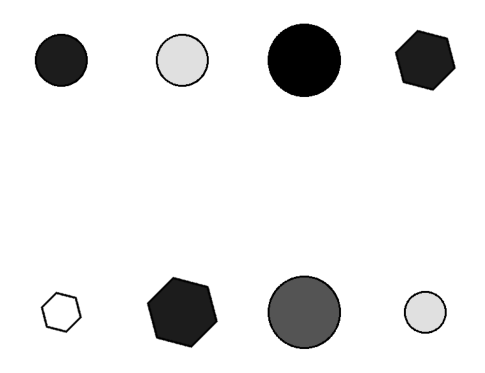

In [5]:
panels = sample['panels']
fig, axes = plt.subplots(2,4, figsize=(6,6))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(panels[i], cmap = 'grey')
    ax.axis('off')
plt.show()

### Pytorch dataset


In [6]:
class RAVENDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.transform = transforms.Compose([transforms.Grayscale(num_output_channels=1),
                                             transforms.ToTensor(),])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        panels = sample['panels']
        choices = sample['choices']
        target = sample['target']

        images = panels + choices
        images = [self.transform(img) for img in images]
        stacked = torch.stack(images, dim =0).squeeze(1)
        return stacked, target

In [7]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
train_dataset = RAVENDataset(resnet_dataset['train'])
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True, generator= torch.Generator(device=device))

val_dataset = RAVENDataset(resnet_dataset['validation'])
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = True, generator= torch.Generator(device=device))

Using device: cuda:0


In [8]:
image, taregt = train_dataset.__getitem__(0)
image.shape

torch.Size([16, 160, 160])

In [9]:
class ResNetBlock(nn.Module):
    def __init__(
            self,
            num_input_filters: int,
            num_output_filters:int,
    )-> None:
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(
                in_channels = num_input_filters,
                out_channels = num_input_filters,
                kernel_size = 3,
                stride = 1,
                padding = 1,
                bias = False,
            ),
            nn.ReLU(),
        )
        self.conv_block2 = nn.Conv2d(
                in_channels = num_input_filters,
                out_channels = num_output_filters,
                kernel_size = 3,
                stride = 1,
                padding = 1,
                bias = False,
            )
        self.conv_block3 = nn.Conv2d(
                in_channels = num_input_filters,
                out_channels = num_output_filters,
                kernel_size = 3,
                stride = 1,
                padding = 1,
                bias = False,
            )
        self.layer_norm1 = None
        self.layer_norm2 = None

    def forward(self, x: torch.Tensor)-> torch.tensor:
        residual = self.conv_block3(x)
        out = self.conv_block1(x)
        _, C, H,W = out.shape
        if self.layer_norm1 == None:
            self.layer_norm1 = nn.LayerNorm([C, H, W])
        out = self.layer_norm1(out)
        out = self.conv_block2(out)
        _, C, H,W = out.shape
        if self.layer_norm2  == None:
            self.layer_norm2 = nn.LayerNorm([C, H, W])
        out = self.layer_norm2(out)
        out = out + residual
        out = F.relu(out)
        return out


In [25]:
num_filters = 32
encoder = nn.Sequential(
    nn.Conv2d(16, num_filters, 3, 1),
    nn.ReLU(),
)
resnet = ResNetBlock(num_input_filters=32, num_output_filters=32)
decoder = nn.Sequential(
            # nn.AdaptiveAvgPool2d((20, 20)),
            nn.Conv2d(
                in_channels=num_filters,
                out_channels=1,
                kernel_size=1,
                stride=1,
                bias=False,
            ),
            # nn.BatchNorm2d(num_features=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(24964, 128),
            nn.ReLU(),
            nn.Linear(128, 8),
            nn.Tanh(),
        )
network = nn.Sequential(
            encoder,
            resnet,
            decoder,
        )
network = network.to(device)


In [26]:
total_params = sum(p.numel() for p in network.parameters())
print(f" Total number of parameters: {total_params}")

 Total number of parameters: 3228872


In [27]:
def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()
            _, preds = outputs.max(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    avg_loss = val_loss / len(val_loader)
    acc = 100. * correct / total
    return avg_loss, acc


In [ ]:
learning_rate = 1e-3
lambda_l2 = 1e-4
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.RMSprop(network.parameters(), lr = learning_rate, weight_decay = lambda_l2)
temperature = 3.0
gamma = 0.99

with device:
    network.train()
    for epoch in range(100):
        for batch, targets in train_loader:
            batch, targets = batch.to(device), targets.to(device)
            y_pred = network(batch)
            loss = criterion(y_pred, targets)
            _, predicted = torch.max(y_pred,1)
            accuracy = (targets == predicted).sum().float()/len(targets)
            print(f"Epoc : {epoch+1} , loss: {loss.item(): .6f}. accuracy: {accuracy: .3f}")

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        val_loss, val_acc = validate(network, val_loader, criterion, device)
        print('-----------validation-----------')
        print(f"Epoch {epoch+1}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")


Epoc : 1 , loss:  2.075120. accuracy:  0.125
Epoc : 1 , loss:  2.596400. accuracy:  0.094
Epoc : 1 , loss:  2.596400. accuracy:  0.062
Epoc : 1 , loss:  2.658900. accuracy:  0.062
Epoc : 1 , loss:  2.596400. accuracy:  0.156
Epoc : 1 , loss:  2.658900. accuracy:  0.094
Epoc : 1 , loss:  2.533900. accuracy:  0.094
Epoc : 1 , loss:  2.783900. accuracy:  0.062
Epoc : 1 , loss:  2.533900. accuracy:  0.156
Epoc : 1 , loss:  2.408900. accuracy:  0.156
Epoc : 1 , loss:  2.471400. accuracy:  0.125
Epoc : 1 , loss:  2.658900. accuracy:  0.094
Epoc : 1 , loss:  2.346400. accuracy:  0.125
Epoc : 1 , loss:  2.346400. accuracy:  0.031
Epoc : 1 , loss:  2.533900. accuracy:  0.125
Epoc : 1 , loss:  2.408900. accuracy:  0.156
Epoc : 1 , loss:  2.783900. accuracy:  0.031
Epoc : 1 , loss:  2.658900. accuracy:  0.031
Epoc : 1 , loss:  2.408900. accuracy:  0.125
Epoc : 1 , loss:  2.596400. accuracy:  0.125
Epoc : 1 , loss:  2.846400. accuracy:  0.031
Epoc : 1 , loss:  2.533900. accuracy:  0.125
Epoc : 1 ,